In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import set_up as setup

In [2]:
path = '/home/investigator/mariandbt/python/data'
path = path + '/20240313_s2simulation'

In [3]:
sns_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
s2_table_path = os.path.join(path, "s2tab/20240405_s2_table.h5")


# $\beta$ $\beta$ event

In [4]:
import s2_signal as s2sig

In [5]:
# ________________________________________________________________________________________________________________
# Global params
# ________________________________________________________________________________________________________________

n_panels = 18
n_sensors = 108

v_drift_EL = 2.5e-3 # [mm]/[ns] = 2.5 [mm]/[us]

n_bb_events_per_file = 1 # we're only gonna get the first event

event_path = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2
list_of_bb_file_paths = [event_path]
n_bb_files = len(list_of_bb_file_paths)

# ________________________________________________________________________________________________________________

s2sig.set_global_parameters(globals(),
                            n_bb_files = n_bb_files,
                            n_bb_events_per_file = n_bb_events_per_file,
                            n_panels = n_panels,
                            n_sensors = n_sensors,
                            v_drift_EL = v_drift_EL,
                            geant4_t_binin_in_ns = 0.1,
                            samplin_rate_in_ns = 25
                           )

Global parameters set successfully :)


In [6]:
start, event, sensor = 0, 0, 202
start, bb_ie, prim_e = s2sig.find_bb_ie(event_path, start, event)

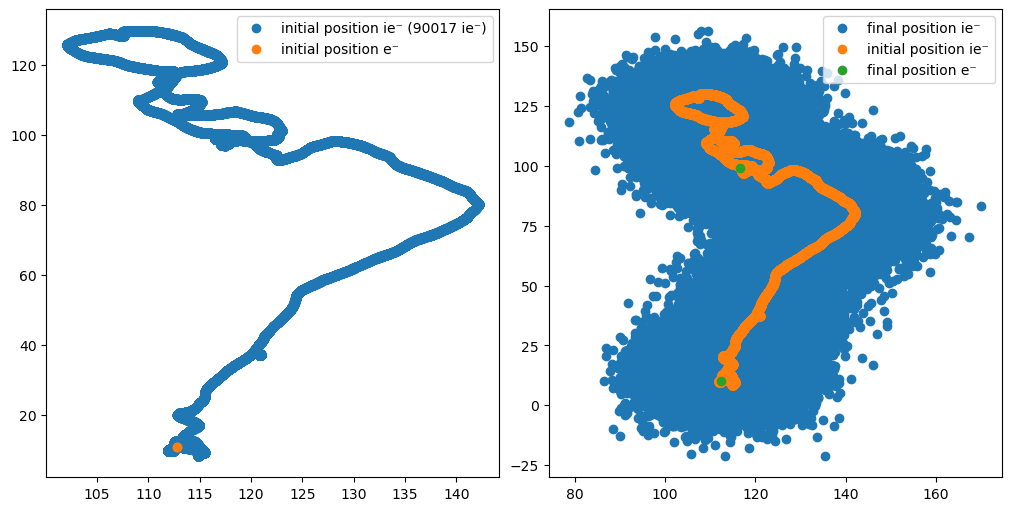

In [7]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_x, prim_e.initial_y, 'o', label = 'initial position e⁻')
ax[0].legend()

ax[1].plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax[1].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
ax[1].plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')
ax[1].legend()

In [29]:
rot = -5

In [30]:
s2bb.BuildSensorsDict(TPC)
s2bb.FindSensor(sensor, rot, TPC)

232

In [31]:
FindSensorV2(sensor, rot, TPC)

232

In [19]:
sensor

202

In [21]:
np.argsort(TPC.SensorTheta.magnitude)

array([ 97,  41,  92,  40,  91,  72,  53,  96,  48,  98,  26,  50,  85,
        78,  86,  95,  31,  59,  38,  49, 102,  30,  79,  54,  80, 105,
        45,  13,  77,  93,  23,  89,  84,  16, 107, 100,  10, 106,  28,
        71,  15,  37,  90,  62,  18,   0,  61,   5,  19,  14,  67,   4,
         7,  35,  60,   1,  44,  17,  69,  22,   9,   6,  24,  64,  20,
         8,  99,  42,  51,  88,  12, 103,  75,  21,  46,  68,   2,  43,
        82,  33,  73,  29, 101,  87,  55,  74,  66,  27,  52,  58,  34,
        47,  25,  11,  70,  32,  63,  81,  94,  57,   3,  56, 104,  76,
        65,  39,  36,  83])

In [22]:
TPC.SensorsPosID, TPC.SensorsIDs[np.argsort(TPC.SensorTheta.magnitude)]

(array([-54., -53., -52., -51., -50., -49., -48., -47., -46., -45., -44.,
        -43., -42., -41., -40., -39., -38., -37., -36., -35., -34., -33.,
        -32., -31., -30., -29., -28., -27., -26., -25., -24., -23., -22.,
        -21., -20., -19., -18., -17., -16., -15., -14., -13., -12., -11.,
        -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
          1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,
         23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
         34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,
         45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.]),
 array([259, 258, 257, 256, 255, 254, 265, 264, 263, 262, 261, 260, 271,
        270, 269, 268, 267, 266, 277, 276, 275, 274, 273, 272, 283, 282,
        281, 280, 279, 278, 289, 288, 287, 286, 285, 284, 295, 294, 293,
        292, 291, 290, 301, 300, 299, 298, 297, 296

In [16]:
def FindSensorV2(sensor_id, rotation, TPC):

    pos     = id_to_pos_dict[sensor_id]

    new_pos = pos - rotation*TPC.SensorsPerPanel

    if (new_pos == TPC.NSensors/2):
        new_pos = -TPC.NSensors/2

    if (new_pos > TPC.NSensors/2):
        new_pos = new_pos%(TPC.NSensors/2)

    if (new_pos < -TPC.NSensors/2):
        new_pos = new_pos%(-TPC.NSensors/2)

    new_sens_id = pos_to_id_dict[new_pos]

    return new_sens_id

In [23]:
pos_to_id_dict   = dict(zip(TPC.SensorsPosID,  TPC.SensorsIDs[np.argsort(TPC.SensorTheta.magnitude)]))
id_to_pos_dict   = dict(zip(TPC.SensorsIDs[np.argsort(TPC.SensorTheta.magnitude)],  TPC.SensorsPosID))


/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


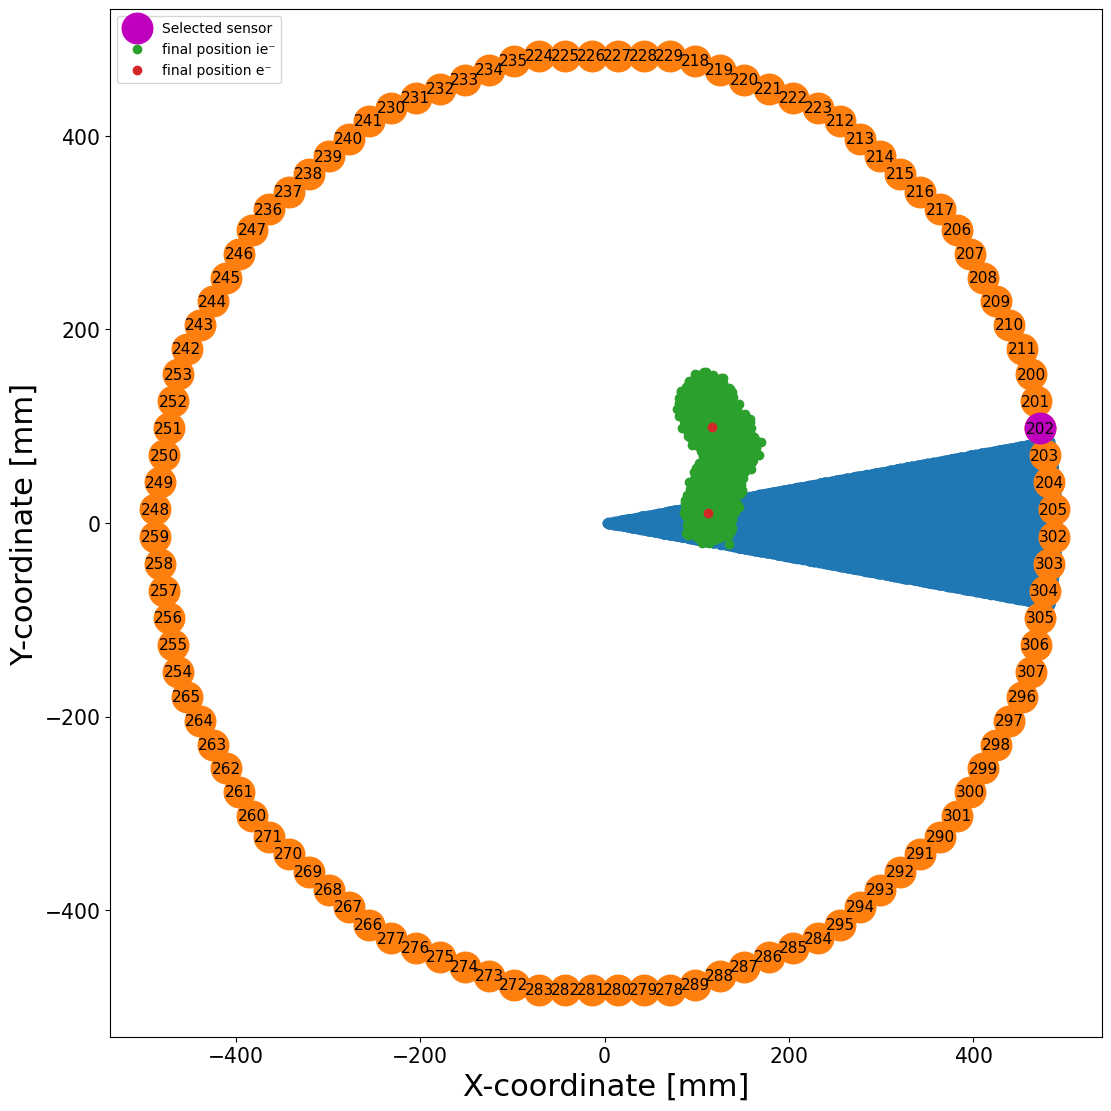

In [8]:
ax = setup.print_sens_geometry(sns_path, sensor)

ax.plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax.plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')

ax.legend(loc= 'upper left')

# Signal waveform

In [9]:
s2_table = setup.read_s2_table(s2_table_path)

In [10]:
s2_signal_path_not_shaped = os.path.join(path, 's2signals/20240521_TEST_bb0nu_1ev_ELoff_s2_signal_20240405s2table.h5')

s2sig.create_s2_signal(s2_table, sns_path, list_of_bb_file_paths, s2_signal_path_not_shaped)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


Sensor 1/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 2/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 3/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 4/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 5/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 6/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 7/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 8/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 9/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 10/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 11/108; Event 1/1; File 1/1
DIRE

DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 87/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 88/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 89/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 90/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 91/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 92/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 93/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  4 prim_e_r =  113.31175505182406
Sensor 94/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 95/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3 prim_e_r =  113.31175505182406
Sensor 96/108; Event 1/1; File 1/1
DIRECT FILE s2_in_pes max =  3

In [11]:
# setup.check_h5(s2_signal_path_not_shaped)

In [12]:
import s2_hists as s2hist

In [13]:
ev = f'{event}'
sens = f'sens_{sensor}'

# Open the HDF5 file in read mode
with h5py.File(s2_signal_path_not_shaped, 'r') as file:

    # Get the group corresponding to the current key
    event_group = file[ev]

    # Get and print the value corresponding to the current subkey
    signal        = event_group[sens]
    s2_not_shaped = np.array(signal['s2_in_pes']) # [pes]
    t_not_shaped  = np.array(signal['time_in_ns'])*1e-3 # [us]

In [14]:
bin_width_in_us = 1 # [us]
# bin_width_in_us = 25e-3 # [us]

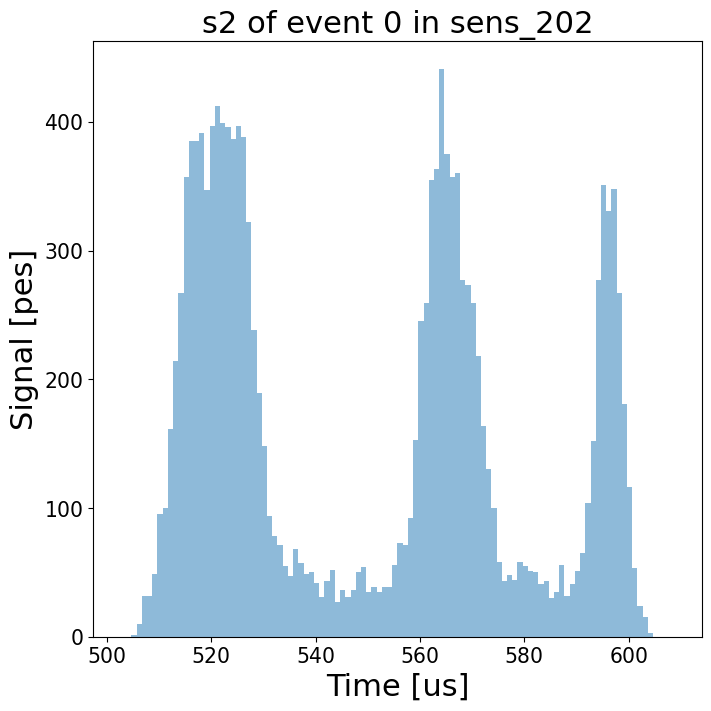

In [15]:

s2_signal, t_in_us, ax = s2hist.print_offline_s2waveform_v2(s2_signal_path_not_shaped, event, sensor, 
                                                            bin_width_in_us = bin_width_in_us, 
                                                            new_figure = True, 
                                                            comment = r'NOT SHAPED (108 sens)')


# Shapin and samplin

In [16]:
# ________________________________________________________________________________________________________________
# Global params
# ________________________________________________________________________________________________________________

shapin_tau_in_ns   = 155 # [ns]
# shapin_tau_in_ns   = 20  # [ns]
samplin_rate_in_ns = 25  # [ns]
t_binin_in_ns      = 1   # [ns]

# ________________________________________________________________________________________________________________

s2sig.shapin_and_samplin(s2_signal_path_not_shaped, shapin_tau_in_ns, samplin_rate_in_ns, t_binin_in_ns)

s2_signal_shaped_sampled_path = s2_signal_path_not_shaped.replace('_s2_signal_', f'_s2_signal_shaped{shapin_tau_in_ns}ns_sampled{samplin_rate_in_ns}ns_')


Sensor 1/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 2/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 3/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 4/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 5/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 6/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 7/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 8/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 9/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 10/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 11/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 12/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 13/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 14/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 15/108; Event 1/1
deltas DONE!
shapin DONE!
samplin DONE!
Sensor 16/108; Event 1/1
deltas DO

In [17]:
# setup.check_h5(s2_signal_shaped_sampled_path)

In [25]:
# samplin_rate_in_us = 1
samplin_rate_in_us = 25e-3


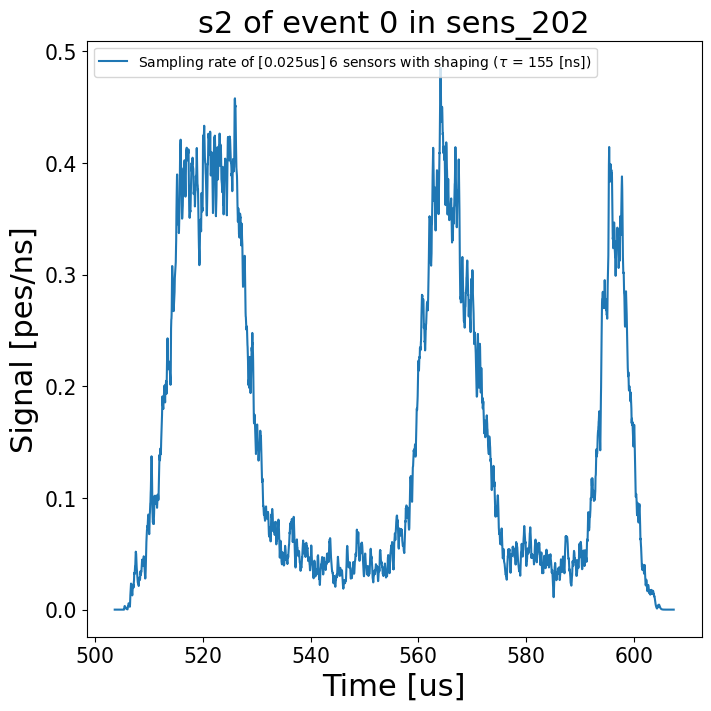

In [26]:

s2_shaped_sampled, t_in_us, ax = s2hist.print_offline_s2waveform(s2_signal_shaped_sampled_path, event, sensor, 
                                                                 t0_in_us = t_not_shaped.min(), 
                                                                 samplin_rate_in_us = samplin_rate_in_us, 
                                                                 new_figure = True, 
                                                                 comment = fr'6 sensors with shaping ($\tau$ = {shapin_tau_in_ns} [ns])')
ax.set_ylabel('Signal [pes/ns]')

ax.legend(loc = 'upper left')

In [27]:
impedance_in_ohm = 50
s2_shaped_sampled_in_mV = s2sig.conversion_to_mV(s2_shaped_sampled, impedance_in_ohm)

(0.0, 17.0)

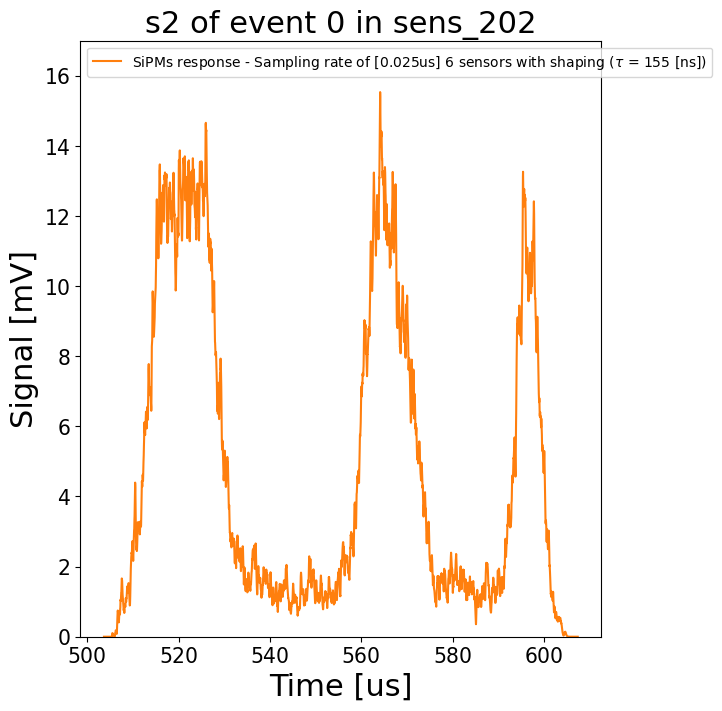

In [28]:
s2_shaped_sampled, t_in_us, ax = s2hist.print_offline_s2waveform(s2_signal_shaped_sampled_path, event, sensor, 
                                                                 t0_in_us = t_not_shaped.min(), 
                                                                 samplin_rate_in_us = samplin_rate_in_us, 
                                                                 new_figure = True, 
                                                                 comment = fr'6 sensors with shaping ($\tau$ = {shapin_tau_in_ns} [ns])')


ax.plot(t_in_us, s2_shaped_sampled_in_mV, label = 'SiPMs response')
ax.set_ylabel('Signal [mV]')

# Access the lines from the ax object
lines = ax.get_lines()

# Remove the second line (cosine wave)
lines[0].remove()

# Store the legend of the line to be removed
line0_legend = lines[0].get_label()
line1_legend = lines[1].get_label()

# Update the remaining line's legend
lines[1].set_label(f'{line1_legend} - {line0_legend}')

ax.legend(loc = 'upper left')

ax.set_ylim(0, 17)



In [33]:
np.trapz(y = s2_shaped_sampled, x = t_in_us*1e3)


15300.574845187348

In [30]:
s2_signal.sum()

15301.0

# $\beta$ $\beta$ event: nexus vs offline

In [8]:

import s2_bb_events as s2bb
from s2_bb_events import unit

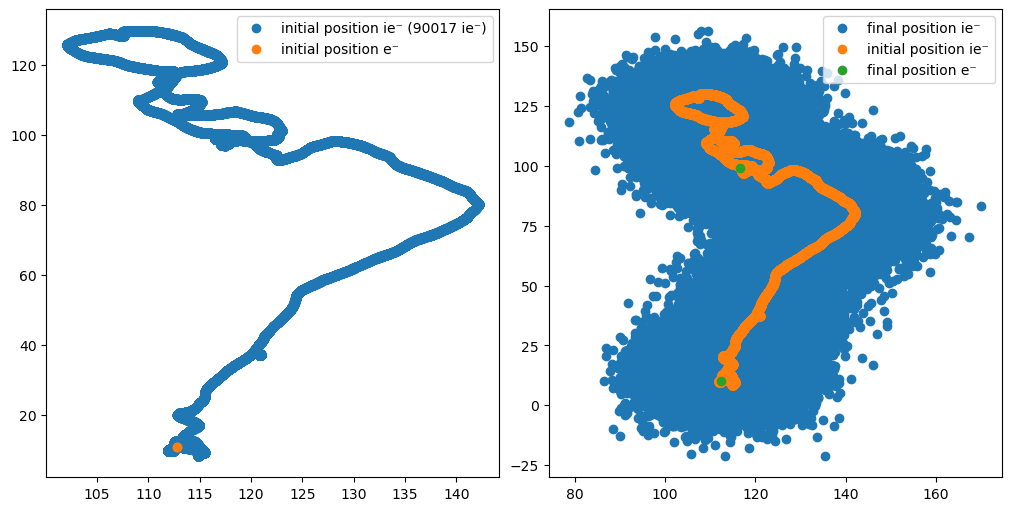

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_x, prim_e.initial_y, 'o', label = 'initial position e⁻')
ax[0].legend()

ax[1].plot(bb_ie.final_x, bb_ie.final_y, 'o', label = 'final position ie⁻')
ax[1].plot(bb_ie.initial_x, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
ax[1].plot(prim_e.final_x, prim_e.final_y, 'o', label = 'final position e⁻')
ax[1].legend()

In [9]:
# Create TPC
TPC     = s2bb.FiberBarrelTPC()
TPC.SetActiveDriftVelocity()
TPC.SetRecombinationFactor()
TPC.SetElectronLifetime()
TPC.SetActiveLongDiffusion()
TPC.SetActiveTransDiffusion()
TPC.SetEL()
TPC.SetSensors(sns_path)

/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [61]:
nexusEvent = s2bb.nexusEvent(event_path, event)
nexusEvent.AddDriftAndDiffusion(TPC)

In [62]:
x, y, t = nexusEvent.ElectronsFinalX, nexusEvent.ElectronsFinalY, nexusEvent.ElectronsMeasurementTime


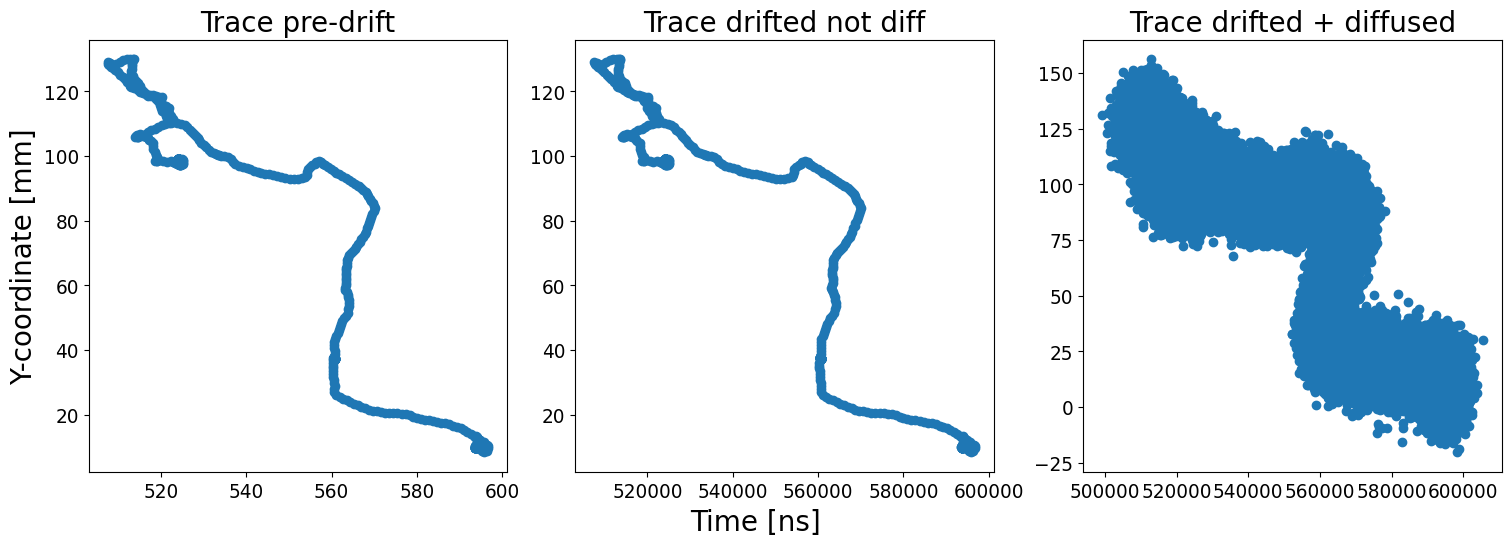

In [63]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,5), constrained_layout=True, sharex=False, sharey=False)
font_size = 20

ax = ax.ravel()
z_not_drift_not_diff  = nexusEvent.HitsZ
t_yes_drift_not_diff  = nexusEvent.HitsTime + nexusEvent.DriftTime
y_not_drift_not_diff  = nexusEvent.HitsY # doesn't change with drift tho

ax[0].plot(z_not_drift_not_diff.magnitude, y_not_drift_not_diff.magnitude, 'o')
ax[1].plot(t_yes_drift_not_diff.magnitude, y_not_drift_not_diff.magnitude, 'o')
ax[2].plot(t.magnitude, y.magnitude, 'o')

fig.text(0.5, -0.05, f'Time [{t.units:~}]', ha='center', fontsize = font_size)
ax[0].set_ylabel(f'Y-coordinate [{y.units:~}]', fontsize = font_size)

for axx, title in zip(ax, ['Trace pre-drift', 'Trace drifted not diff', 'Trace drifted + diffused']):
    axx.tick_params(axis='both', which = 'both', labelsize = font_size*2/3)
    axx.set_title(title, fontsize = font_size)

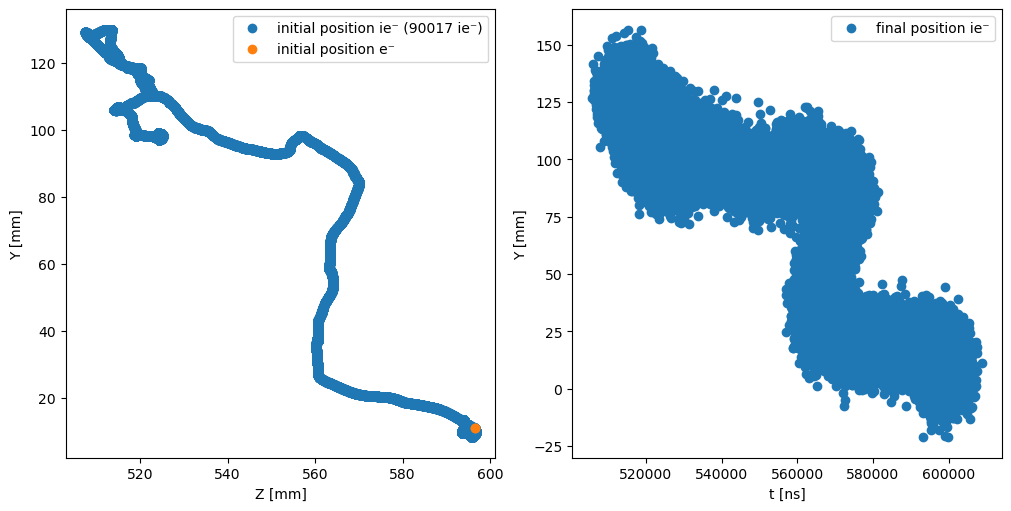

In [64]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5), constrained_layout=True, sharex=False, sharey=False)

# Transfer the content from the original axes to the new subplot

ax[0].plot(bb_ie.initial_z, bb_ie.initial_y, 'o', label = f'initial position ie⁻ ({len(bb_ie)} ie⁻)')
ax[0].plot(prim_e.initial_z, prim_e.initial_y, 'o', label = 'initial position e⁻')

ax[0].set_xlabel('Z [mm]')
ax[0].set_ylabel('Y [mm]')
ax[0].legend()

ax[1].plot(bb_ie.final_t, bb_ie.final_y, 'o', label = 'final position ie⁻')
# ax[1].plot(bb_ie.initial_t, bb_ie.initial_y, 'o', label = 'initial position ie⁻')
# ax[1].plot(prim_e.final_t, prim_e.final_y, 'o', label = 'final position e⁻')

ax[1].set_xlabel('t [ns]')
ax[1].set_ylabel('Y [mm]')
ax[1].legend()

# $\beta$ $\beta$ signal reconstruction: offline